# Quantium Virtual Internship - Experimentation and Uplift Testing - Task 2

## 1. Loading and Cleaning the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("QVI_data.csv")
df

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream
...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget


In [3]:
# Renamed the column names to meaningful and business-friendly names
df = df.rename(columns = {"LYLTY_CARD_NBR" : "loyalty_card_number",
                          "DATE" : "date",
                          "STORE_NBR" : "store_number",
                          "TXN_ID" : "transaction_id",
                          "PROD_NBR" : "product_number",
                          "PROD_NAME" : "product",
                          "PROD_QTY" : "quantity",
                          "TOT_SALES" : "sales",
                          "PACK_SIZE" : "pack_size_in_gms",
                          "BRAND" : "product_brand",
                          "LIFESTAGE" : "life_stage",
                          "PREMIUM_CUSTOMER" : "spending_segment"})

# Reordered columns to follow a logical, business-friendly structure and maintain consistency with Task 1, making the 
#            dataset easier to read, analyze, and work with throughout the project.
df = df[["transaction_id", "date", "loyalty_card_number", "store_number", "product_number", "product", "product_brand", "pack_size_in_gms", 
   "quantity", "sales", "life_stage", "spending_segment"]]

In [4]:
# Checked datatype of each column
df.dtypes

transaction_id           int64
date                       str
loyalty_card_number      int64
store_number             int64
product_number           int64
product                    str
product_brand              str
pack_size_in_gms         int64
quantity                 int64
sales                  float64
life_stage                 str
spending_segment           str
dtype: object

In [5]:
# Converted datatype of date column from str to date
df["date"] = pd.to_datetime(df["date"])

In [6]:
# Checked for null values
df.isnull().sum()

transaction_id         0
date                   0
loyalty_card_number    0
store_number           0
product_number         0
product                0
product_brand          0
pack_size_in_gms       0
quantity               0
sales                  0
life_stage             0
spending_segment       0
dtype: int64

In [7]:
# Checked for duplicate records
df.duplicated().sum()

np.int64(1)

In [8]:
# Removed duplicate records
df = df.drop_duplicates()

In [9]:
# Summary stats of numerical columns
df.describe()

,transaction_id,date,loyalty_card_number,store_number,product_number,pack_size_in_gms,quantity,sales
count,2.648330e+05,264833,2.648330e+05,264833.000000,264833.000000,264833.000000,264833.000000,264833.000000
mean,1.351577e+05,2018-12-30 00:52:39.666658,1.355489e+05,135.079529,56.583598,182.425540,1.905812,7.299351
min,1.000000e+00,2018-07-01 00:00:00,1.000000e+03,1.000000,1.000000,70.000000,1.000000,1.500000
25%,6.760000e+04,2018-09-30 00:00:00,7.002100e+04,70.000000,28.000000,150.000000,2.000000,5.400000
50%,1.351370e+05,2018-12-30 00:00:00,1.303570e+05,130.000000,56.000000,170.000000,2.000000,7.400000
75%,2.027000e+05,2019-03-31 00:00:00,2.030940e+05,203.000000,85.000000,175.000000,2.000000,9.200000
max,2.415841e+06,2019-06-30 00:00:00,2.373711e+06,272.000000,114.000000,380.000000,5.000000,29.500000
std,7.813305e+04,NaN,8.058003e+04,76.784189,32.826498,64.325268,0.343437,2.527244


## 2. Preparing the Pre-Trial Data

In [10]:
# 1. Filter for the pre-trial period only (July 2018 to January 2019)
pre_trial_df = df[df['date'] < '2019-02-01'].copy()

# 2. Create the Year-Month period column for proper chronological sorting
pre_trial_df['year_month'] = pre_trial_df['date'].dt.to_period('M')

# 3. Create the pivot table for pre-trial monthly sales for each store
pre_trial_pivot = pd.pivot_table(
    pre_trial_df, 
    index="store_number", 
    columns="year_month", 
    values="sales",
    aggfunc="sum"
)

# 4. Format headers to readable Month Year strings
pre_trial_pivot.columns = pre_trial_pivot.columns.strftime('%B %Y')

# View the resulting pre-trial pivot table
pre_trial_pivot

year_month,July 2018,August 2018,September 2018,October 2018,November 2018,December 2018,January 2019
store_number,,,,,,,
1,206.9,176.10,278.8,188.1,192.6,189.6,154.8
2,150.8,193.80,154.4,167.8,162.9,136.0,162.8
3,1205.7,1079.75,1021.5,1037.9,1008.0,1121.6,1051.7
4,1399.9,1259.50,1198.6,1346.4,1212.0,1185.6,1525.0
5,812.0,745.10,896.0,798.0,771.4,879.2,838.0
...,...,...,...,...,...,...,...
268,224.0,322.65,174.4,237.6,225.4,207.3,157.7
269,982.0,835.10,886.0,1078.4,967.2,935.4,980.4
270,962.8,1003.75,845.4,816.4,965.0,1038.0,1066.6


In [11]:
# Create the pivot table for unique customers per month for each store
customers_pivot = pd.pivot_table(
    pre_trial_df, 
    index="store_number", 
    columns="year_month", 
    values="loyalty_card_number", 
    aggfunc="nunique"
)

# Format headers
customers_pivot.columns = customers_pivot.columns.strftime('%B %Y')
customers_pivot

year_month,July 2018,August 2018,September 2018,October 2018,November 2018,December 2018,January 2019
store_number,,,,,,,
1,49.0,42.0,59.0,44.0,46.0,42.0,35.0
2,39.0,39.0,36.0,41.0,39.0,35.0,43.0
3,112.0,112.0,102.0,104.0,101.0,111.0,102.0
4,128.0,123.0,119.0,123.0,118.0,104.0,134.0
5,93.0,97.0,101.0,88.0,85.0,95.0,92.0
...,...,...,...,...,...,...,...
268,48.0,50.0,31.0,47.0,49.0,42.0,37.0
269,103.0,109.0,100.0,111.0,106.0,107.0,110.0
270,96.0,122.0,101.0,96.0,101.0,101.0,117.0


In [12]:
# 1. Group by store and month to calculate total transactions and unique customers
store_monthly_metrics = pre_trial_df.groupby(['store_number', 'year_month']).agg(
    total_transactions=('transaction_id', 'count'),
    unique_customers=('loyalty_card_number', 'nunique')
).reset_index()

# 2. Calculate the average transactions per customer
store_monthly_metrics['avg_tx_per_customer'] = (
    store_monthly_metrics['total_transactions'] / store_monthly_metrics['unique_customers']
)

# 3. Pivot this result into your monthly format
avg_tx_pivot = pd.pivot_table(
    store_monthly_metrics,
    index="store_number",
    columns="year_month",
    values="avg_tx_per_customer"
)

# 4. Format headers
avg_tx_pivot.columns = avg_tx_pivot.columns.strftime('%B %Y')
avg_tx_pivot

year_month,July 2018,August 2018,September 2018,October 2018,November 2018,December 2018,January 2019
store_number,,,,,,,
1,1.061224,1.023810,1.050847,1.022727,1.021739,1.119048,1.028571
2,1.051282,1.102564,1.027778,1.048780,1.025641,1.085714,1.046512
3,1.232143,1.196429,1.166667,1.144231,1.168317,1.162162,1.186275
4,1.250000,1.227642,1.159664,1.260163,1.177966,1.278846,1.253731
5,1.290323,1.154639,1.237624,1.215909,1.305882,1.315789,1.282609
...,...,...,...,...,...,...,...
268,1.083333,1.080000,1.096774,1.021277,1.040816,1.023810,1.027027
269,1.349515,1.211009,1.240000,1.333333,1.283019,1.242991,1.309091
270,1.447917,1.262295,1.247525,1.239583,1.316832,1.475248,1.324786


## 3. Creating the Store Matching Function

In [13]:
def calculate_similarity(trial_store, candidate_store, pivot_df):
    """
    Calculates Pearson correlation (trend alignment) and normalized magnitude 
    distance (scale/volume alignment) between a trial store and a candidate store.
    """
    # Extract the monthly time series for both stores
    trial_vals = pivot_df.loc[trial_store]
    cand_vals = pivot_df.loc[candidate_store]
    
    # 1. Pearson Correlation
    corr = trial_vals.corr(cand_vals)
    if np.isnan(corr): 
        corr = 0
        
    # 2. Magnitude Distance
    # Calculate absolute differences, average them, and invert it so 1 is identical and 0 is distant
    abs_diff = np.abs(trial_vals - cand_vals)
    # Normalize by the average size of the trial store to make scales comparable
    norm_diff = abs_diff.mean() / trial_vals.mean()
    magnitude = 1 / (1 + norm_diff)
    
    return corr, magnitude

## 4. Finding the Best Control Stores

In [14]:
# To globally suppress the runtime and user warnings in your Jupyter Notebook
import warnings
warnings.filterwarnings('ignore')

trial_store = 88
results = []

# Loop through every unique store in your data
for store in pre_trial_pivot.index:
    # Skip comparing the trial store to itself
    if store in [77, 86, 88]: 
        continue
        
    try:
        # Calculate similarities across all 3 metrics
        sales_corr, sales_mag = calculate_similarity(trial_store, store, pre_trial_pivot)
        cust_corr, cust_mag = calculate_similarity(trial_store, store, customers_pivot)
        tx_corr, tx_mag = calculate_similarity(trial_store, store, avg_tx_pivot)

        # Combine them into a composite score (giving equal weight to correlation and magnitude)
        # Typically we average the Sales and Customer metrics as required by the task

        combined_score = (sales_corr + sales_mag + cust_corr + cust_mag) / 4
        # Note: tx_corr and tx_mag (avg transactions/customer) are calculated above but 
        # deliberately excluded from the score. This metric barely varies across stores 
        # (~1.0-1.3 for almost all of them), so it doesn't help distinguish good matches 
        # from bad ones - including it just dilutes the more meaningful sales/customer signal.
        
        results.append({
            'candidate_store': store,
            'sales_correlation': sales_corr,
            'sales_magnitude': sales_mag,
            'customer_correlation': cust_corr,
            'customer_magnitude': cust_mag,
            'combined_score': combined_score
        })
    except KeyError:
        # Skips stores that might have missing historical months
        continue

# Convert results to a DataFrame and sort by the highest score
score_df = pd.DataFrame(results).sort_values(by='combined_score', ascending=False)

# Look at the top 5 closest matches for Store 77
score_df.head(5)

,candidate_store,sales_correlation,sales_magnitude,customer_correlation,customer_magnitude,combined_score
173,178,0.731857,0.767719,0.939466,0.850242,0.822321
232,237,0.308479,0.958234,0.947326,0.987654,0.800423
108,113,0.495763,0.760193,0.862632,0.824742,0.735833
68,69,0.450029,0.774867,0.815792,0.886203,0.731723
196,201,0.492735,0.887607,0.511302,0.927292,0.704734


In [15]:
trial_stores = [77, 86, 88]
final_controls = {}

for t_store in trial_stores:
    results = []
    for store in pre_trial_pivot.index:
        # Do not pick a trial store as a control store
        if store in trial_stores:
            continue
            
        try:
            sales_corr, sales_mag = calculate_similarity(t_store, store, pre_trial_pivot)
            cust_corr, cust_mag = calculate_similarity(t_store, store, customers_pivot)
            
            combined_score = (sales_corr + sales_mag + cust_corr + cust_mag) / 4
            results.append({'candidate_store': store, 'combined_score': combined_score})
        except KeyError:
            continue
            
    # Find the store with the highest score for this specific trial store
    best_match = pd.DataFrame(results).sort_values(by='combined_score', ascending=False).iloc[0]
    final_controls[t_store] = int(best_match['candidate_store'])

print("Matched Control Stores:", final_controls)

Matched Control Stores: {77: 233, 86: 155, 88: 178}


## 5. Checking the Pre-Trial Trends (Visual Validation)

In [16]:
def plot_pre_trial_validation(trial_store, control_store):
    """
    Generates side-by-side line charts comparing a trial store and its control store
    across Sales, Customer counts, and Average Transactions during the pre-trial period.
    """
    # Set up the plotting style and layout (1 row, 3 columns)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Pre-Trial Trend Validation: Store {trial_store} vs Control Store {control_store}", 
                 fontsize=16, fontweight='bold', y=1.05)
    
    # List of pivot dataframes, their titles, and y-axis labels
    metrics = [
        (pre_trial_pivot, "Monthly Sales", "Total Sales ($)"),
        (customers_pivot, "Monthly Customers", "Unique Customers"),
        (avg_tx_pivot, "Avg Transactions per Customer", "Transactions / Customer")
    ]
    
    # Loop through the metrics to create the 3 plots
    for idx, (pivot_df, title, ylabel) in enumerate(metrics):
        ax = axes[idx]
        
        # Extract x-axis (months) and y-axis data for both stores
        months = pivot_df.columns
        trial_data = pivot_df.loc[trial_store]
        control_data = pivot_df.loc[control_store]
        
        # Plot lines
        ax.plot(months, trial_data, marker='o', linewidth=2.5, color='#1f77b4', label=f'Trial (Store {trial_store})')
        ax.plot(months, control_data, marker='s', linewidth=2.5, color='#ff7f0e', linestyle='--', label=f'Control (Store {control_store})')
        
        # Formatting
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel("Month", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        ax.legend(loc='upper left')
        
    plt.tight_layout()
    plt.show()

#### 5.1 Store 77 vs Control Store 233 Validation

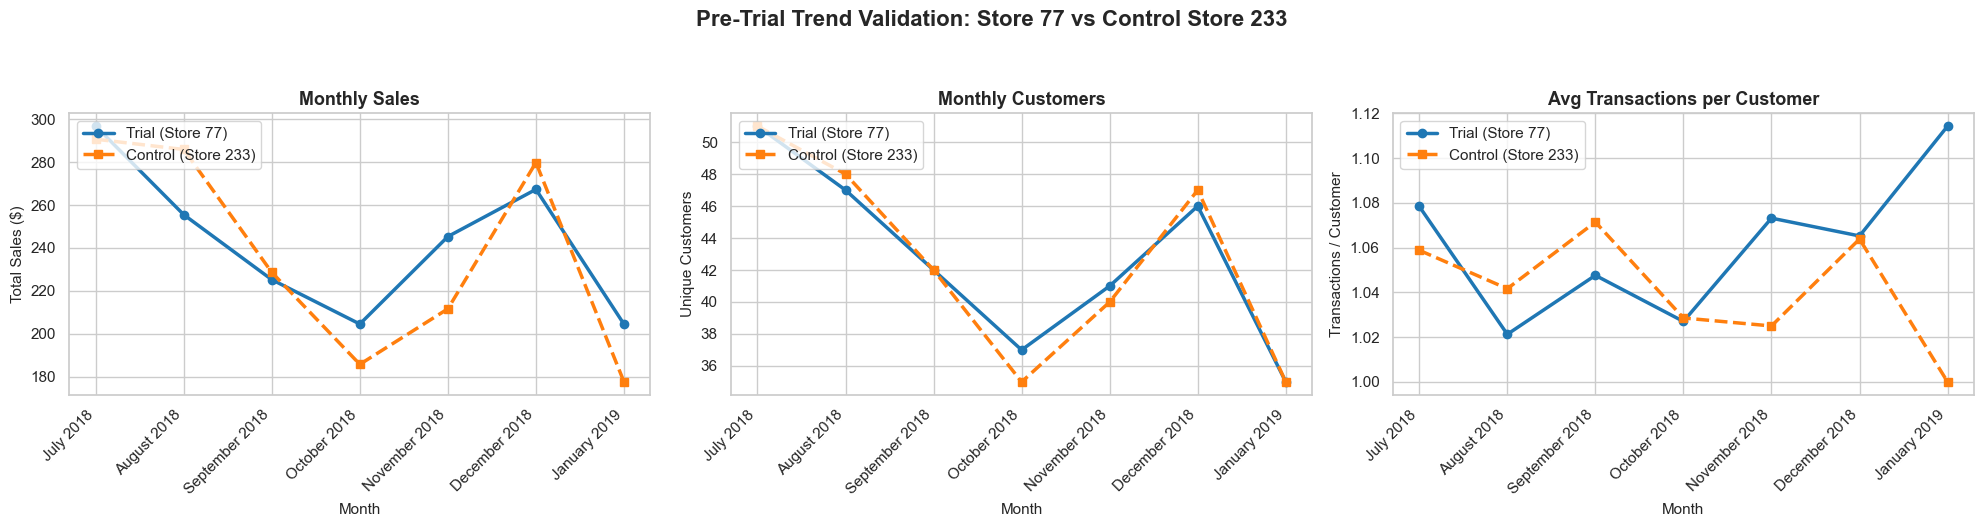

In [17]:
# Validate Store 77
plot_pre_trial_validation(trial_store=77, control_store=233)

#### 5.2 Store 86 vs Control Store 155 Validation

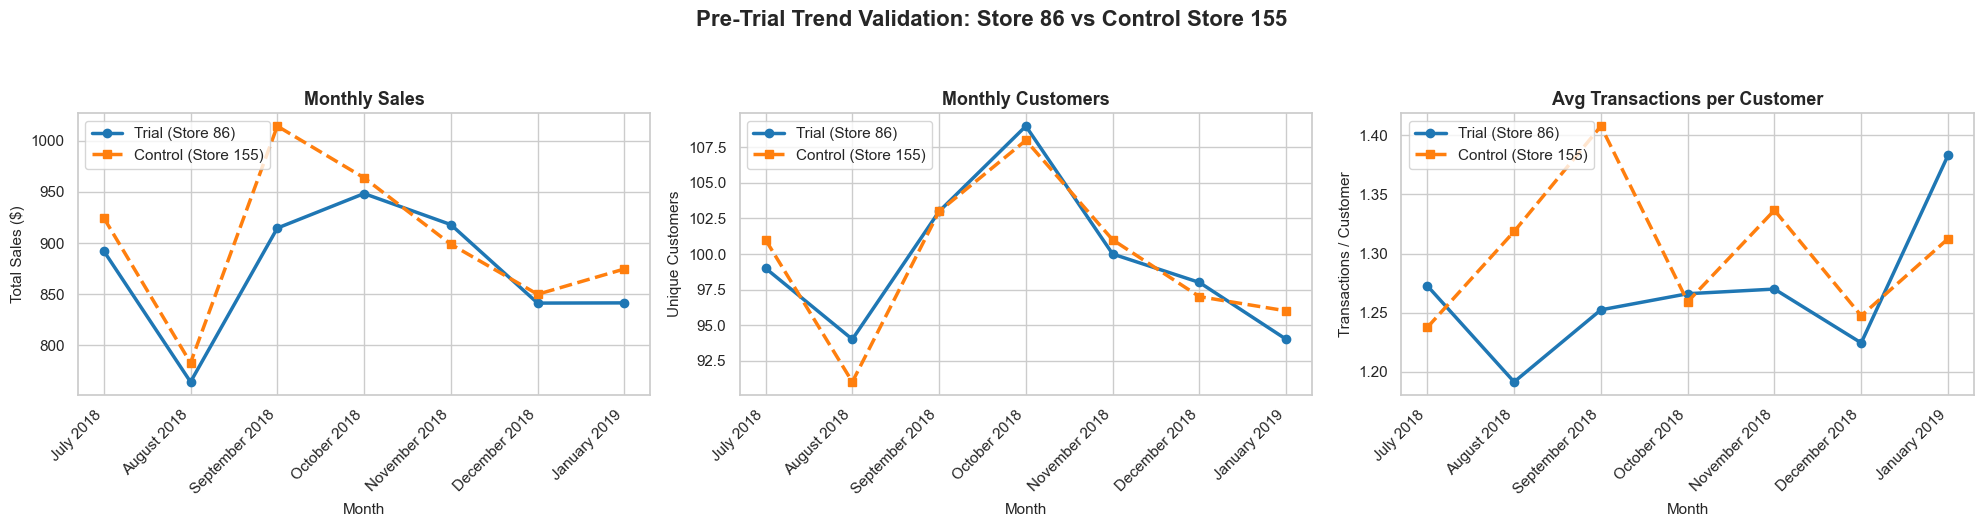

In [18]:
# Validate Store 86
plot_pre_trial_validation(trial_store=86, control_store=155)

#### 5.3 Store 88 vs Control Store 178 Validation

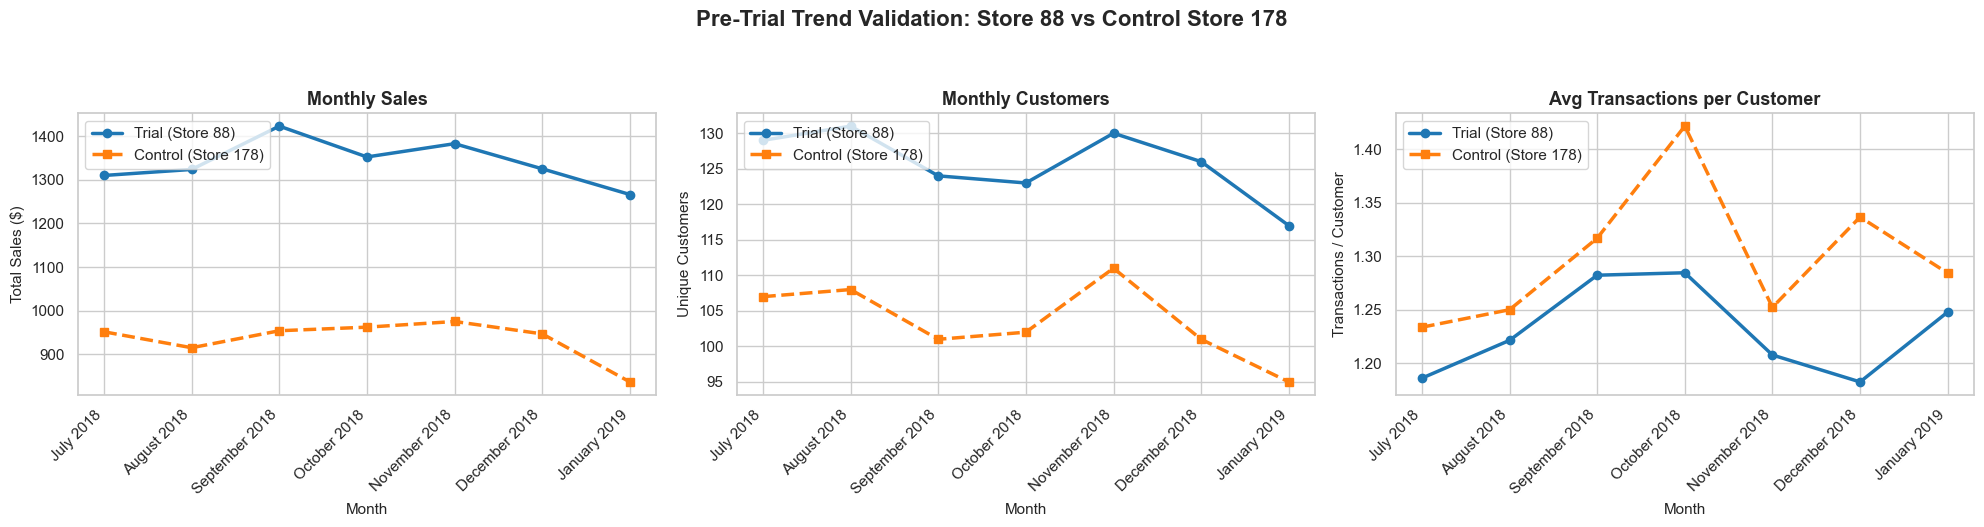

In [19]:
# Validate Store 88
plot_pre_trial_validation(trial_store=88, control_store=178)

## 6. Calculating Trial Performance and Uplift

In [20]:
# 1. Filter original dataframe for the trial period (Feb 2019 to Apr 2019)
trial_period_df = df[(df['date'] >= '2019-02-01') & (df['date'] <= '2019-04-30')].copy()
trial_period_df['year_month'] = trial_period_df['date'].dt.to_period('M')

# 2. Re-calculate the core metrics for the trial months
# Sales Pivot
sales_trial = pd.pivot_table(trial_period_df, index="store_number", columns="year_month", values="sales", aggfunc="sum")
# Customers Pivot
cust_trial = pd.pivot_table(trial_period_df, index="store_number", columns="year_month", values="loyalty_card_number", aggfunc="nunique")

# Avg Transactions per Customer Pivot
tx_metrics = trial_period_df.groupby(['store_number', 'year_month']).agg(
    total_tx=('transaction_id', 'count'),
    unique_cust=('loyalty_card_number', 'nunique')
).reset_index()
tx_metrics['avg_tx'] = tx_metrics['total_tx'] / tx_metrics['unique_cust']
tx_trial = pd.pivot_table(tx_metrics, index="store_number", columns="year_month", values="avg_tx")

# Convert column names to readable string format ('February 2019', etc.)
for df_t in [sales_trial, cust_trial, tx_trial]:
    df_t.columns = df_t.columns.strftime('%B %Y')

# Define your store pairs
store_pairs = {77: 233, 86: 155, 88: 178}

In [21]:
def plot_trial_comparison(trial_store, control_store):
    """
    Plots side-by-side bar charts comparing Trial vs Control store performance
    and prints the percentage uplift for each metric during the trial months.
    """
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f"Trial Period Performance: Store {trial_store} vs Control Store {control_store} (Feb - Apr 2019)", 
                 fontsize=16, fontweight='bold', y=1.05)
    
    metrics = [
        (sales_trial, "Monthly Sales ($)", "Total Sales"),
        (cust_trial, "Unique Customers", "Total Customers"),
        (tx_trial, "Avg Transactions / Customer", "Avg Transactions")
    ]
    
    print(f"--- UPLIFT METRICS FOR STORE {trial_store} vs CONTROL STORE {control_store} ---")
    
    for idx, (pivot_df, ylabel, title) in enumerate(metrics):
        ax = axes[idx]
        months = pivot_df.columns
        
        # Pull values for the specific store pair
        trial_vals = pivot_df.loc[trial_store].values
        control_vals = pivot_df.loc[control_store].values
        
        # Calculate and print % Uplift for the notebook output text
        uplift_pct = ((trial_vals - control_vals) / control_vals) * 100
        for m, up in zip(months, uplift_pct):
            print(f"{title} Uplift in {m}: {up:+.2f}%")
        print("-" * 50)
            
        # Structure data for seaborn plotting
        plot_data = pd.DataFrame({
            'Month': np.repeat(months, 2),
            'Value': np.ravel(list(zip(trial_vals, control_vals))),
            'Store Type': ['Trial', 'Control'] * len(months)
        })
        
        # Plot grouped bar chart
        sns.barplot(data=plot_data, x='Month', y='Value', hue='Store Type', 
                    palette=['#1f77b4', '#ff7f0e'], ax=ax)
        
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlabel("Trial Months", fontsize=11)
        plt.setp(ax.get_xticklabels(), rotation=15)
        ax.legend(loc='upper right')
        
    plt.tight_layout()
    plt.show()

#### 6.1 Store 77 Uplift Performance

--- UPLIFT METRICS FOR STORE 77 vs CONTROL STORE 233 ---
Total Sales Uplift in February 2019: -3.69%
Total Sales Uplift in March 2019: +39.88%
Total Sales Uplift in April 2019: +66.14%
--------------------------------------------------
Total Customers Uplift in February 2019: +0.00%
Total Customers Uplift in March 2019: +25.00%
Total Customers Uplift in April 2019: +56.67%
--------------------------------------------------
Avg Transactions Uplift in February 2019: -4.26%
Avg Transactions Uplift in March 2019: +7.32%
Avg Transactions Uplift in April 2019: -7.16%
--------------------------------------------------


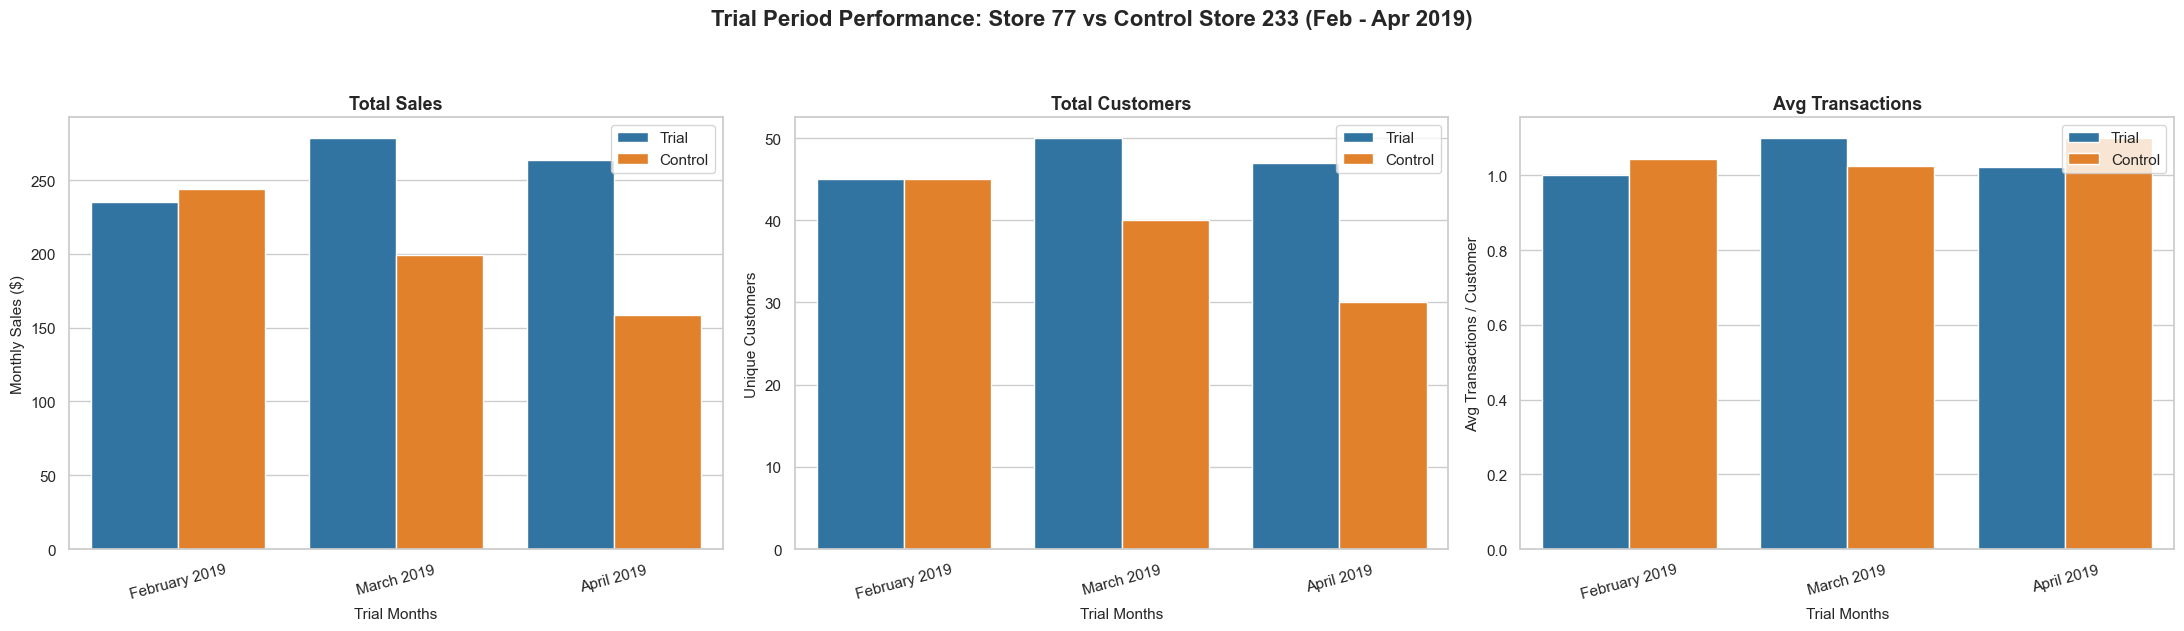

In [22]:
# Evaluate Store 77
plot_trial_comparison(trial_store=77, control_store=233)

#### 6.2 Store 86 Uplift Performance

--- UPLIFT METRICS FOR STORE 86 vs CONTROL STORE 155 ---
Total Sales Uplift in February 2019: +2.47%
Total Sales Uplift in March 2019: +27.65%
Total Sales Uplift in April 2019: +0.43%
--------------------------------------------------
Total Customers Uplift in February 2019: +12.63%
Total Customers Uplift in March 2019: +22.34%
Total Customers Uplift in April 2019: +6.06%
--------------------------------------------------
Avg Transactions Uplift in February 2019: -2.83%
Avg Transactions Uplift in March 2019: -3.28%
Avg Transactions Uplift in April 2019: -1.04%
--------------------------------------------------


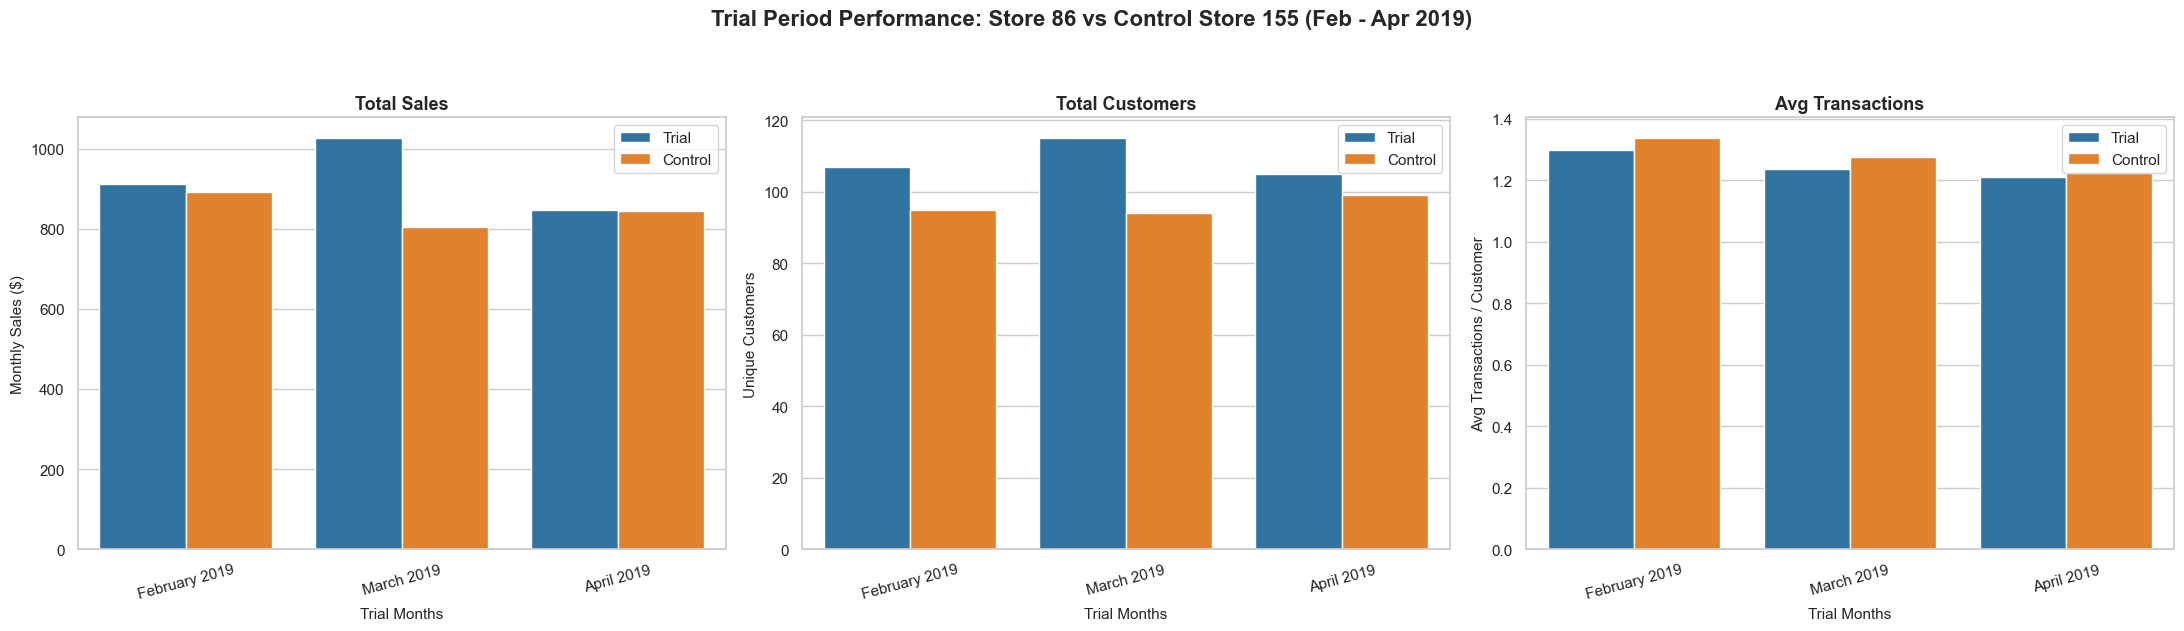

In [23]:
# Evaluate Store 86
plot_trial_comparison(trial_store=86, control_store=155)

#### 6.3 Store 88 Uplift Performance

--- UPLIFT METRICS FOR STORE 88 vs CONTROL STORE 178 ---
Total Sales Uplift in February 2019: +25.84%
Total Sales Uplift in March 2019: +47.90%
Total Sales Uplift in April 2019: +35.82%
--------------------------------------------------
Total Customers Uplift in February 2019: +15.89%
Total Customers Uplift in March 2019: +17.54%
Total Customers Uplift in April 2019: +9.40%
--------------------------------------------------
Avg Transactions Uplift in February 2019: -9.60%
Avg Transactions Uplift in March 2019: +1.14%
Avg Transactions Uplift in April 2019: -1.28%
--------------------------------------------------


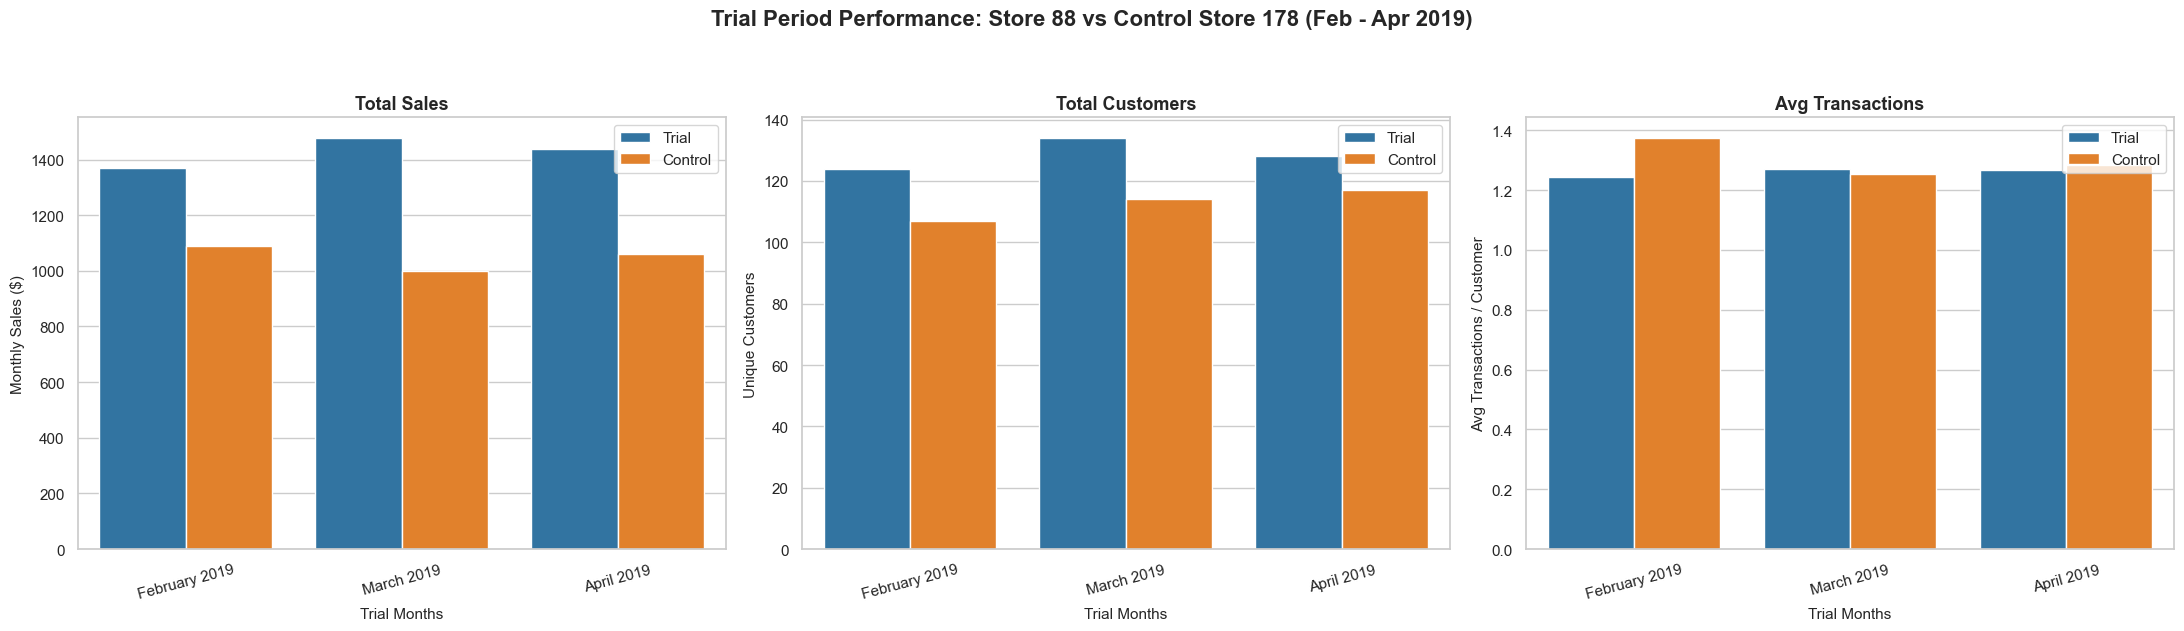

In [24]:
# Evaluate Store 88
plot_trial_comparison(trial_store=88, control_store=178)

## 7. Key Insights

We compared each trial store to a similar "control" store that did not get the new layout, 
to see if sales moved differently once the trial started. Note: these are observed 
percentage differences, not confirmed through formal statistical testing, so they should be 
read as trends rather than proven results.

- **Store 77**: Sales dipped slightly in February (-3.69%) but then rose sharply — up 39.88% 
  in March and 66.14% in April, compared to its control store. Customer numbers grew in the 
  same pattern (up to +56.67% in April), suggesting more people visited the store after the 
  layout change, rather than existing customers simply spending more per visit.

- **Store 86**: Results were smaller and less consistent. Sales rose 27.65% in March but were 
  almost flat in February (+2.47%) and April (+0.43%). Customer numbers were up in all three 
  months, but average spend per visit was slightly down throughout — more people came in, but 
  this didn't fully translate into extra sales.

- **Store 88**: Sales were up in all three months (25.84%, 47.90%, 35.82%), the most 
  consistent result of the three stores. Customer numbers also rose steadily, while average 
  transactions per customer stayed roughly flat — again pointing to more visits as the main 
  driver, not bigger baskets.

**Overall**: All three trial stores showed higher sales and more customers than their control 
stores during the trial. Store 88 was the most consistent performer, Store 77 had the 
strongest late-trial growth, and Store 86 showed the weakest and most uneven results.

## 8. Business Recommendations

Based on these observed trends, we recommend:

1) Move forward with rolling out the new layout, starting with stores similar to 77 and 88, 
   where sales and customer growth were strongest and most consistent.

2) Keep a close eye on results after rollout to confirm the sales gains hold up over a longer 
   period, since this trial only covered three months.

3) Look into why Store 86 performed more weakly — for example, whether local competition, 
   store size, or customer type made the layout less effective there.

4) Pair the new layout with in-store promotions to encourage bigger purchases, since the main 
   gain so far has been more visits rather than more spend per visit.

5) Test the layout in a wider range of stores before a full rollout, to make sure the results 
   aren't specific to just these three locations.